# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# set this so the graphs open internally
%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv). 

### Step 3. Assign it to a variable called chipo.

In [2]:
chipo = pd.read_csv("https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv", sep='\t')

### Step 4. See the first 10 entries

In [3]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### Step 5. Create a histogram of the top 5 items bought

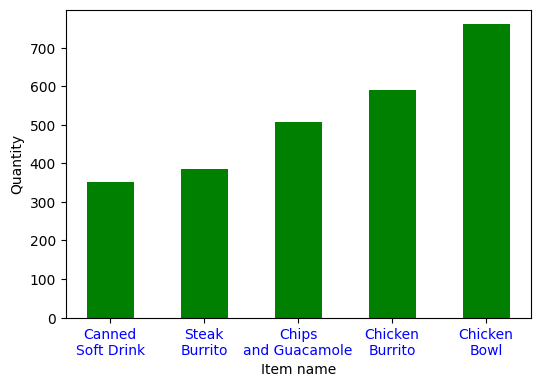

In [10]:
# quantity_dict = {}
# item_names = list(set(list(chipo.iloc[:]["item_name"])))
# for curr_item in item_names:
#     quantity_dict[curr_item] = chipo.loc[chipo["item_name"] == curr_item, "quantity"].sum()

# quantity_dict = dict(sorted(quantity_dict.items(), key=lambda item: item[1])[-5:])

# # Plot a histogram
# plt.figure(figsize=(6, 4))
# labels = [k.replace(" ", "\n", 1) for k in quantity_dict.keys()]  # readability
# plt.bar(labels, quantity_dict.values(), width=0.5, color='g')

# # for readability
# plt.xlabel('Item name');
# plt.ylabel('Quantity');
# plt.xticks(color='blue');

sorted_quantity_df = chipo.groupby(["item_name"])[["quantity"]].sum().sort_values(by=["quantity"])
top_5_items = sorted_quantity_df[-5:]

# Plot a histogram
plt.figure(figsize=(6, 4))
labels = [k.replace(" ", "\n", 1) for k in top_5_items.index]  # readability
plt.bar(labels, top_5_items["quantity"], width=0.5, color='g')

# for readability
plt.xlabel('Item name');
plt.ylabel('Quantity');
plt.xticks(color='blue');

### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

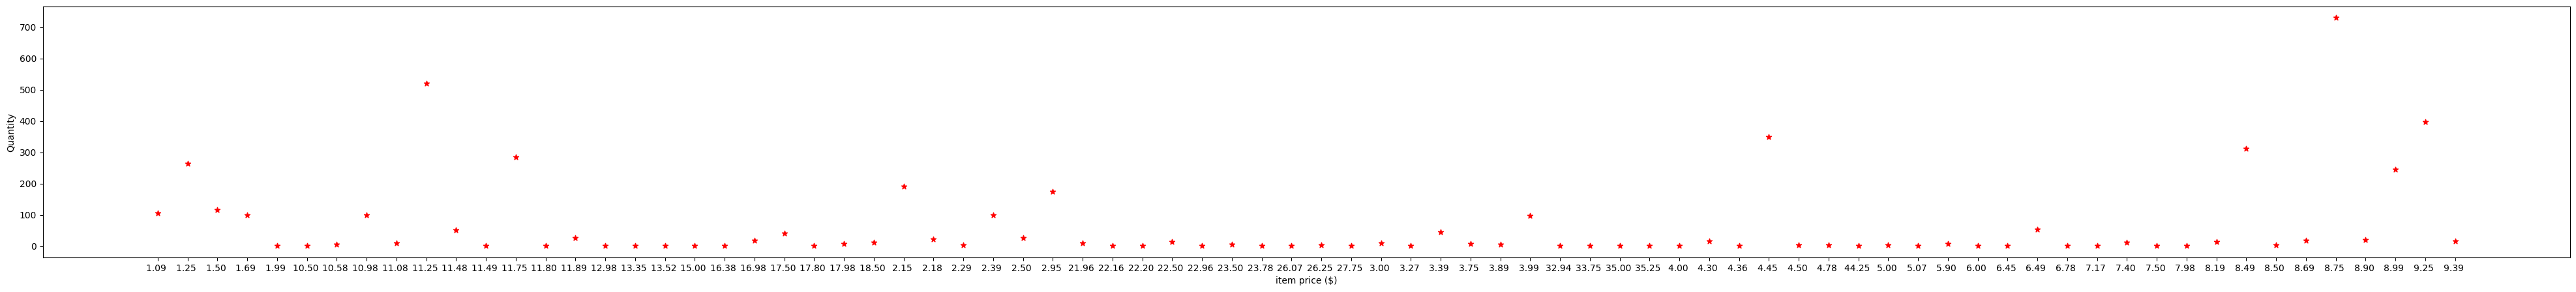

In [14]:
orders_per_price_df = chipo.groupby(["item_price"])[["quantity"]].count()
orders_per_price_df.sort_values(by=["item_price"])

modify_price = lambda x : x[1:]
new_price_list = orders_per_price_df.index.map(modify_price)  # .map : apply lambda function on the index column
# new_price_list = [price[1:] for price in orders_per_price_df.index]

plt.figure(figsize=(50, 5));
plt.scatter(new_price_list, orders_per_price_df["quantity"], marker='*', c="Red");
plt.xlabel("item price ($)");
plt.ylabel("Quantity");

### Step 7. BONUS: Create a question and a graph to answer your own question.

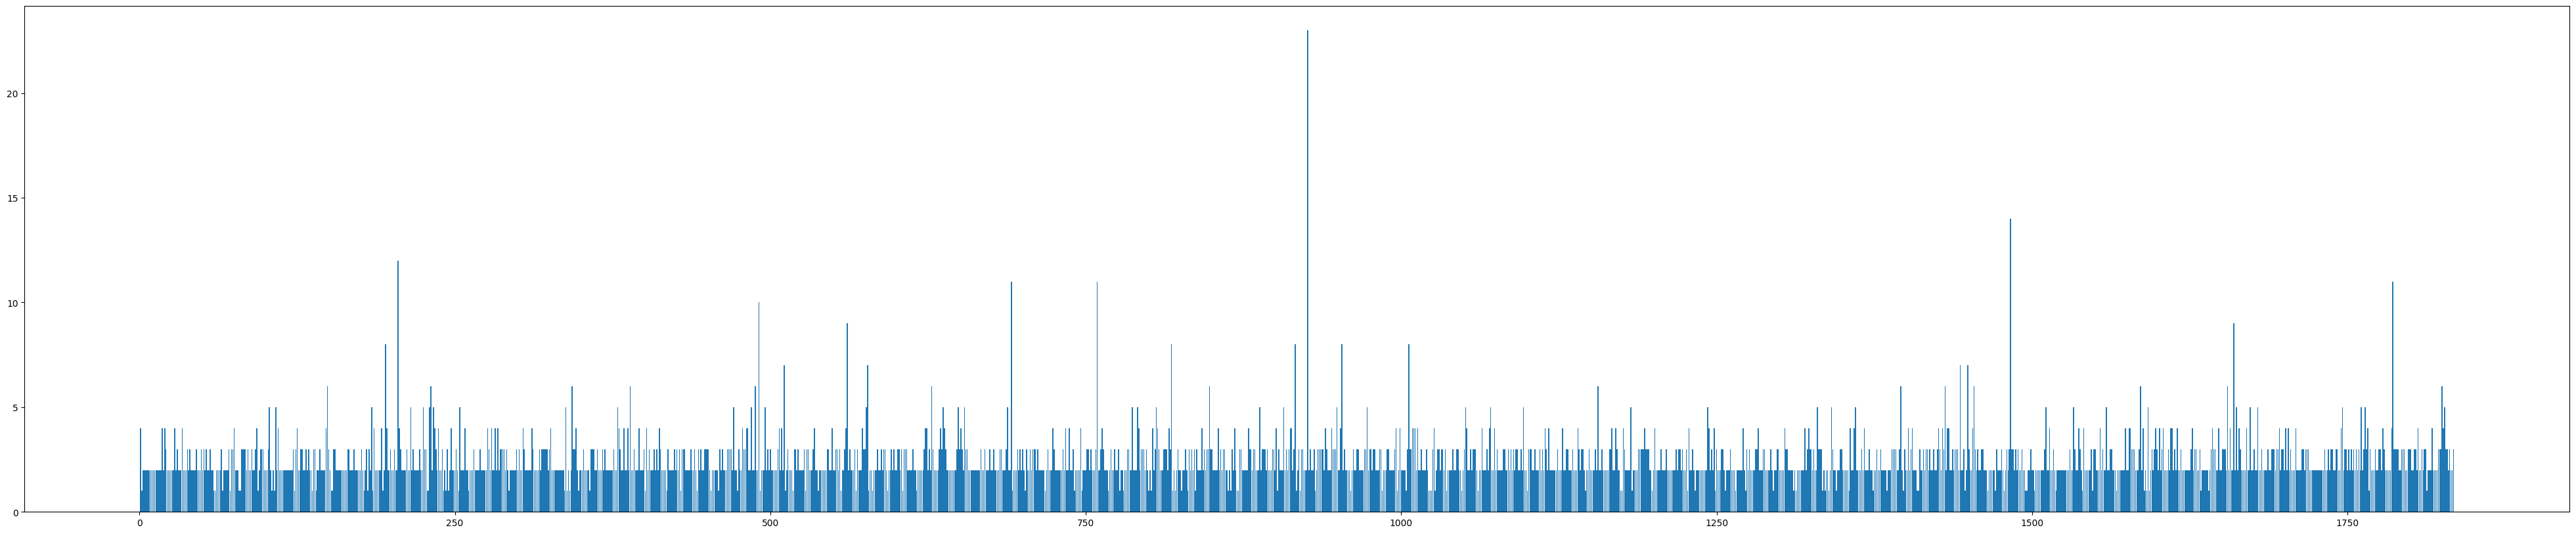

In [16]:
# Question: create a bar plot of the order id
order_id_count = chipo.groupby(["order_id"])["order_id"].count()

# labels = list(set(chipo["order_id"]))
labels = chipo["order_id"].unique()

ax = plt.figure(figsize=(50, 10));
# plt.plot(labels, order_id_count);
plt.bar(labels, order_id_count);